# Clasificación de familias de instrumentos musicales mediante CNN

Este notebook implementa un clasificador de familias de instrumentos musicales
(brass, strings, winds, keyboards) basado en una red neuronal convolucional (CNN)
que trabaja sobre mel-spectrogramas como imágenes 2D.

**Dataset de entrenamiento:** TinySOL (2.913 muestras de notas aisladas)  
**Validación externa:** Philharmonia, IRMAS y NSynth  
**Clases:** brass, strings, winds, keyboards

In [3]:
#Librerías base del proyecto
import os
from pathlib import Path

import pandas as pd
import numpy as np
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Dataset

Se utiliza **TinySOL**, un dataset de notas musicales aisladas grabadas en el IRCAM (París).

| Familia | Instrumentos | Muestras |
|---|---|---|
| Brass | Horn, Trombone, Trumpet, Bass Tuba | 455 |
| Strings | Violin, Viola, Violoncello, Contrabass | 1.193 |
| Winds | Flute, Oboe, Clarinet, Bassoon, Saxophone | 576 |
| Keyboards | Accordion | 689 |
| **Total** | | **2.913** |

La clasificación se plantea a nivel de familia instrumental (4 clases).

**Descarga:** https://zenodo.org/records/3685367

## Preparación del dataset

Los archivos se cargan desde Google Drive en Google Colab. La estructura
de carpetas (familia → instrumento) permite extraer las etiquetas
automáticamente desde la ruta.

Se construye un DataFrame con columnas `path`, `familia` e `instrumento`.
Las etiquetas se normalizan y codifican como índices numéricos
(brass=0, keyboards=1, strings=2, winds=3).

Se analiza la duración de los audios para fijar una longitud uniforme
en el preprocesado.

In [1]:
#Conexión a drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Configuración general del proyecto

#Ruta principal del dataset
RUTA = "/content/drive/MyDrive/TINYSOL"

#Parámetros de audio
SR = 16000 #Frecuencia de muestreo
DURATION = 6.0
SAMPLES = int(SR * DURATION)

#Parámetros del espectrograma Mel
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

#Tamaño de entrada de las imágenes para la CNN
IMG_HEIGHT = 96
IMG_WIDTH = 96

#Parámetros de entrenamiento
BATCH_SIZE = 64
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE

In [5]:
#Construcción del DataFrame con rutas y etiquetas
registros = []

for root, dirs, files in os.walk(RUTA):
    for file in files:
        if file.lower().endswith(".wav"):
            path = os.path.join(root, file)
            partes = path.split("/")

            idx = partes.index("TINYSOL")
            familia = partes[idx + 1]
            instrumento = partes[idx + 2]

            registros.append({
                "path": path,
                "familia": familia,
                "instrumento": instrumento
            })

df = pd.DataFrame(registros)

In [6]:
#Limpieza y normalización de etiquetas

df["familia"] = df["familia"].str.lower().str.strip()
df["instrumento"] = df["instrumento"].str.lower().str.strip()

In [7]:
#Vista general del dataset

print("Número total de audios:", len(df))
print()

print("Audios por familia:")
print(df["familia"].value_counts())
print()

print("Audios por instrumento:")
print(df["instrumento"].value_counts())

Número total de audios: 2913

Audios por familia:
familia
strings      1193
keyboards     689
winds         576
brass         455
Name: count, dtype: int64

Audios por instrumento:
instrumento
accordion      689
contrabass     309
viola          309
violoncello    291
violin         284
horn           134
bassoon        126
clarinet_bb    126
flute          118
trombone       117
bass_tuba      108
oboe           107
sax_alto        99
trumpet_c       96
Name: count, dtype: int64


In [8]:
#Codificación de etiquetas

class_names = sorted(df["familia"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}

df["label"] = df["familia"].map(class_to_index)

num_classes = len(class_names)

print("Familias codificadas:")
print(class_to_index)
print()
print("Número de clases:", num_classes)

Familias codificadas:
{'brass': 0, 'keyboards': 1, 'strings': 2, 'winds': 3}

Número de clases: 4


### 2.3 Construcción del dataset de espectrogramas

Una vez estructurado el dataset a nivel de audio, cada señal se transforma en un espectrograma Mel, una representación tiempo–frecuencia que permite convertir señales unidimensionales en matrices bidimensionales adecuadas para una CNN.

Cada audio se carga con una frecuencia de muestreo fija (`SR=16000`) y posteriormente se ajusta a una duración uniforme (`6 s`) mediante truncado o relleno con ceros. Esto garantiza que todas las muestras tengan la misma longitud temporal.

A continuación, se calcula el espectrograma Mel a partir de la STFT utilizando `N_FFT=1024`, `HOP_LENGTH=256` y `N_MELS=128`. Esta representación reorganiza las frecuencias según la escala Mel, aproximando la forma en que el sistema auditivo humano distribuye la percepción de frecuencia.

Posteriormente, el espectrograma se transforma a escala logarítmica (dB) para comprimir el rango dinámico y resaltar patrones relevantes. Después, se normaliza al intervalo `[0,1]` para estabilizar el entrenamiento.

Finalmente, se añade una dimensión de canal y la representación se redimensiona a `96×96`, obteniendo una entrada homogénea para la red neuronal.

El resultado es un conjunto de tensores que contiene los espectrogramas, las etiquetas numéricas asociadas a cada muestra y las rutas originales de los archivos, permitiendo tanto el entrenamiento como el análisis posterior de resultados.

In [9]:
#Función que transforma un audio en un log-mel spectrogram
def load_audio_make_mel(path):
    y, sr = librosa.load(path, sr=SR, mono=True)

    #Ajuste de longitud para que todos los audios tengan el mismo número de muestras
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    #Cálculo del mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    #Paso a escala logarítmica en decibelios
    mel_db = librosa.power_to_db(mel, ref=np.max)

    #Normalización al intervalo [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    #Añadir canal y redimensionar para adaptarlo a la entrada de la CNN
    mel_db = mel_db[..., np.newaxis]
    mel_db = tf.image.resize(mel_db, [IMG_HEIGHT, IMG_WIDTH]).numpy()

    return mel_db.astype(np.float32)

In [15]:
#Precomputación del dataset de espectrogramas

specs_all = []
#Lista donde se almacenan los espectrogramas

labels_all = []
#Lista de etiquetas numéricas asociadas a cada muestra

paths_all = []
#Lista de rutas originales para mantener la trazabilidad

for i, row in df.iterrows():
    path = row["path"]
    label = row["label"]

    try:
        #Transformación audio -> espectrograma
        spec = load_audio_make_mel(path)

        specs_all.append(spec)
        labels_all.append(label)
        paths_all.append(path)

    except Exception as e:
        #Control de errores para evitar que un archivo detenga todo el proceso
        print(f"Error en {path}: {e}")

    if (i + 1) % 200 == 0:
        #Seguimiento del progreso
        print(f"{i + 1} audios procesados")

specs_all = np.array(specs_all, dtype=np.float32)
#Conversión a array de espectrogramas

labels_all = np.array(labels_all, dtype=np.int32)
#Conversión a array de etiquetas

paths_all = np.array(paths_all)
#Conversión a array de rutas

print("Shape de specs_all:", specs_all.shape)
print("Shape de labels_all:", labels_all.shape)
print("Número total de muestras:", len(specs_all))

200 audios procesados
400 audios procesados
600 audios procesados
800 audios procesados
1000 audios procesados
1200 audios procesados
1400 audios procesados
1600 audios procesados
1800 audios procesados
2000 audios procesados
2200 audios procesados
2400 audios procesados
2600 audios procesados
2800 audios procesados
Shape de specs_all: (2913, 96, 96, 1)
Shape de labels_all: (2913,)
Número total de muestras: 2913


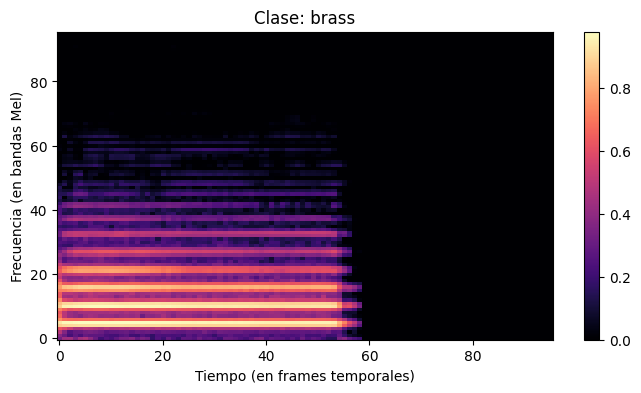

In [12]:
#Visualización de un espectrograma - Ejemplo

plt.figure(figsize=(8, 4))
#Tamaño de la figura

plt.imshow(specs_all[0, :, :, 0], aspect="auto", origin="lower", cmap="magma")
#Se muestra el primer espectrograma del dataset
#El índice 0 final elimina la dimensión del canal
#origin="lower" sitúa las frecuencias bajas en la parte inferior

plt.title(f"Clase: {class_names[labels_all[0]]}")
#Familia instrumental asociada

plt.xlabel("Tiempo (en frames temporales)")
plt.ylabel("Frecuencia (en bandas Mel)")

plt.colorbar()
#Barra de color asociada a la intensidad

plt.show()

# 2. Aplicación

## Separación en train, validation y test

El conjunto de datos se divide de forma estratificada en tres subconjuntos:

- **Train (70%)**: utilizado para ajustar los parámetros de la red neuronal durante el entrenamiento.
- **Validation (15%)**: empleado para monitorizar el aprendizaje y ajustar hiperparámetros durante el entrenamiento.
- **Test (15%)**: reservado exclusivamente para la evaluación final del modelo.

La estratificación garantiza que la proporción de familias instrumentales se mantenga aproximadamente constante en los tres subconjuntos.

In [16]:
#Separación en train, validation y test

specs_train, specs_temp, labels_train, labels_temp, paths_train, paths_temp = train_test_split(
    specs_all,
    labels_all,
    paths_all,
    test_size=0.30,        #30% reservado para validación + test
    random_state=42,       #Reproducibilidad
    stratify=labels_all    #Mantener proporción de clases
)

specs_val, specs_test, labels_val, labels_test, paths_val, paths_test = train_test_split(
    specs_temp,
    labels_temp,
    paths_temp,
    test_size=0.50,        #Divide el 30% en 15% validación y 15% test
    random_state=42,
    stratify=labels_temp   #Mantener proporción de clases
)

print("Train:", len(specs_train))
print("Validation:", len(specs_val))
print("Test:", len(specs_test))
print("Total:", len(specs_all))

Train: 2039
Validation: 437
Test: 437
Total: 2913


## Arquitectura y compilación de la CNN

CNN con capas convolucionales y de pooling progresivas que aprende
patrones locales en el dominio tiempo–frecuencia.

| Parámetro | Valor |
|---|---|
| Optimizador | Adam |
| Función de pérdida | Sparse categorical crossentropy |
| Métrica | Accuracy |

In [17]:
#Definición de la CNN

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    #Forma de entrada de cada espectrograma

    tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    #Extracción de patrones locales simples

    tf.keras.layers.MaxPooling2D((2, 2)),
    #Reducción de la dimensión espacial

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    #Extracción de patrones de mayor complejidad

    tf.keras.layers.MaxPooling2D((2, 2)),
    #Nueva reducción de resolución

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    #Extracción de características de nivel más alto

    tf.keras.layers.MaxPooling2D((2, 2)),
    #Reducción adicional de la dimensión espacial

    tf.keras.layers.Flatten(),
    #Conversión de los mapas de características en un vector

    tf.keras.layers.Dense(64, activation="relu"),
    #Capa densa para combinar las características aprendidas

    tf.keras.layers.Dropout(0.3),
    #Regularización para reducir sobreajuste

    tf.keras.layers.Dense(num_classes, activation="softmax")
    #Salida multiclase en forma de probabilidades
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,444 (2.34 MB)

 Trainable params: 613,444 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Compilación del modelo

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    #Optimizador utilizado para actualizar los pesos

    loss='sparse_categorical_crossentropy',
    #Función de pérdida para etiquetas enteras

    metrics=['accuracy']
    #Métrica principal de evaluación
)

### 3.3 Callbacks

Durante el entrenamiento se incorporan *callbacks* para adaptar dinámicamente el comportamiento del modelo en función de su rendimiento sobre el conjunto de validación.

Se utilizan dos mecanismos complementarios:

- **EarlyStopping:** detiene el entrenamiento cuando la pérdida en validación deja de mejorar durante varias épocas consecutivas. Esto ayuda a evitar el sobreajuste y reduce el tiempo de entrenamiento innecesario.

- **ReduceLROnPlateau:** disminuye automáticamente el *learning rate* cuando el aprendizaje se estanca. Reducir la tasa de aprendizaje en etapas avanzadas permite realizar ajustes más finos de los pesos y favorecer una convergencia más estable.

Ambos mecanismos monitorizan `val_loss`, ya que la pérdida sobre el conjunto de validación proporciona una estimación más representativa de la capacidad de generalización del modelo que las métricas obtenidas sobre los datos de entrenamiento.

In [19]:
#Definición de callbacks

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",          #Métrica de validación a monitorizar
        patience=5,                  #Número de épocas sin mejora antes de detener el entrenamiento
        restore_best_weights=True    #Restaura los pesos del mejor modelo encontrado
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",          #Métrica de validación a monitorizar
        factor=0.5,                  #Factor de reducción del learning rate
        patience=2                   #Épocas sin mejora antes de reducir el learning rate
    )
]

### 3.4 Entrenamiento

El modelo se entrena utilizando los espectrogramas del conjunto de entrenamiento junto con las etiquetas numéricas asociadas a cada muestra.

Las etiquetas se proporcionan en formato entero, lo que resulta coherente con el uso de la función de pérdida `sparse_categorical_crossentropy`. El entrenamiento se realiza por lotes (*batches*), donde cada iteración procesa un conjunto de `64` muestras.

Además, se utiliza el conjunto de validación para monitorizar el rendimiento del modelo durante el entrenamiento. Las métricas obtenidas permiten evaluar su capacidad de generalización y activar automáticamente los mecanismos definidos mediante *callbacks*.

In [20]:
#Entrenamiento del modelo

history = model.fit(
    specs_train,
    labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(specs_val, labels_val),
    callbacks=callbacks,
    verbose=1  #Muestra el progreso del entrenamiento por época
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 643ms/step - accuracy: 0.6253 - loss: 0.9750 - val_accuracy: 0.7895 - val_loss: 0.5640 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 697ms/step - accuracy: 0.8264 - loss: 0.4749 - val_accuracy: 0.8856 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 648ms/step - accuracy: 0.8887 - loss: 0.3085 - val_accuracy: 0.9130 - val_loss: 0.2246 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 772ms/step - accuracy: 0.9235 - loss: 0.2012 - val_accuracy: 0.9199 - val_loss: 0.1778 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step - accuracy: 0.9485 - loss: 0.1451 - val_accuracy: 0.9497 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 656ms/step - accuracy: 0.9573 - loss: 0.1111 - val_accuracy: 0.9565 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 640ms/step - accuracy: 0.9613 - loss: 0.

#3. Evaluación

## 3.1 Resultados

La evaluación se realiza sobre el conjunto de test, correspondiente al 15% del dataset y no utilizado durante el entrenamiento ni durante el ajuste de hiperparámetros.

Para analizar el rendimiento del modelo se utilizan varias métricas complementarias:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** porcentaje de muestras predichas como pertenecientes a una clase que realmente pertenecen a ella.
- **Recall:** capacidad del modelo para identificar correctamente las muestras de una clase.
- **F1-score:** media armónica entre precisión y recall.
- **Matriz de confusión:** representación detallada de las predicciones correctas y errores entre clases.

Estas métricas permiten evaluar tanto el rendimiento global del modelo como su comportamiento específico para cada familia instrumental.

In [21]:
#Predicciones sobre el conjunto de test

#Probabilidades predichas para cada clase
pred_probs = model.predict(specs_test, verbose=0)

#Clase predicha como el índice de mayor probabilidad
y_pred = np.argmax(pred_probs, axis=1)

#Etiquetas reales del conjunto de test
y_true = labels_test

In [24]:
#Porcentaje de aciertos del modelo en el conjunto de test
print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification report:")
#Incluye precision, recall y F1-score por clase
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.9588100686498856

Classification report:
              precision    recall  f1-score   support

       brass       0.85      0.93      0.89        68
   keyboards       1.00      0.99      1.00       104
     strings       0.99      0.99      0.99       179
       winds       0.94      0.88      0.91        86

    accuracy                           0.96       437
   macro avg       0.94      0.95      0.95       437
weighted avg       0.96      0.96      0.96       437



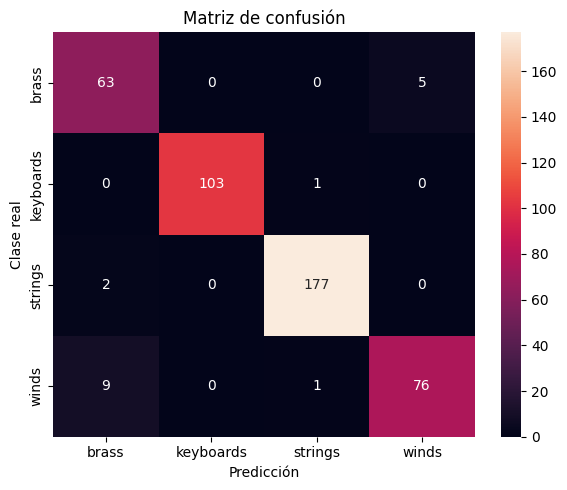

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")

plt.tight_layout()
plt.show()

## 3.2 Análisis cualitativo por clase

Además de las métricas cuantitativas, se realiza un análisis cualitativo de las predicciones del modelo para estudiar cómo toma sus decisiones.

Para cada familia instrumental se seleccionan ejemplos correctamente clasificados con alta confianza, con el objetivo de identificar patrones recurrentes presentes en los espectrogramas Mel.

Para cada muestra se registran:

- **Clase real:** familia instrumental correcta.
- **Clase predicha:** familia asignada por el modelo.
- **Confidence:** probabilidad máxima asignada a la clase predicha.
- **Margin:** diferencia entre las probabilidades de las dos clases más probables.

La visualización de estas muestras permite relacionar las decisiones del modelo con características observables en la representación tiempo–frecuencia y analizar qué patrones parecen resultar más discriminativos para cada familia instrumental.

In [26]:
#Predicción de una sola muestra ya preprocesada
def predict_single_spec(spec):
    """
    Devuelve:
    - pred_idx: clase predicha
    - probs: vector de probabilidades
    """
    x = np.expand_dims(spec, axis=0)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return pred_idx, probs

In [27]:
#Construcción de una tabla de resultados con información detallada de cada predicción del modelo
records = []

for spec, path, true_idx in zip(specs_test, paths_test, labels_test):
    pred_idx, probs = predict_single_spec(spec)

    sorted_probs = np.sort(probs)[::-1]
    top1 = float(sorted_probs[0])
    top2 = float(sorted_probs[1])
    margin = top1 - top2

    records.append({
        "path": str(path),
        "true_idx": int(true_idx),
        "true_class": class_names[int(true_idx)],
        "pred_idx": pred_idx,
        "pred_class": class_names[pred_idx],
        "correct": int(pred_idx == int(true_idx)),
        "confidence": top1,
        "second_prob": top2,
        "margin": margin,
        "probs": probs
    })

results_df = pd.DataFrame(records)


In [28]:
#Función auxiliar: Visualización de un acierto
def show_correct_case(row):
    idx = results_df.index[results_df["path"] == row["path"]][0]
    spec = specs_test[idx]

    plt.figure(figsize=(8, 4))
    plt.imshow(spec[:, :, 0], aspect="auto", origin="lower", cmap="magma")

    plt.title(
        f"Clase: {row['true_class']} | "
        f"Confianza: {row['confidence']:.3f} | "
        f"Margen: {row['margin']:.3f}"
    )

    plt.xlabel("Frames temporales")
    plt.ylabel("Bandas de frecuencia (escala Mel)")

    plt.colorbar(label="Intensidad normalizada")

    plt.tight_layout()
    plt.show()

In [29]:
#Subconjunto de aciertos
correct_df = results_df[results_df["correct"] == 1].copy()
print("Aciertos:", len(correct_df))

#Selección de los aciertos más seguros por clase
top_correct_per_class = []

for cls in class_names:
    subset = correct_df[correct_df["true_class"] == cls].copy()
    subset = subset.sort_values("confidence", ascending=False).head(3)
    top_correct_per_class.append(subset)

top_correct_per_class = pd.concat(top_correct_per_class).reset_index(drop=True)

top_correct_per_class[["true_class", "pred_class", "confidence", "margin", "path"]]

Aciertos: 419


,true_class,pred_class,confidence,margin,path
0,brass,brass,0.999983,0.999975,/content/drive/MyDrive/TINYSOL/Brass/Bass_Tuba...
1,brass,brass,0.999982,0.999968,/content/drive/MyDrive/TINYSOL/Brass/Bass_Tuba...
2,brass,brass,0.999977,0.999959,/content/drive/MyDrive/TINYSOL/Brass/Bass_Tuba...
3,keyboards,keyboards,1.000000,1.000000,/content/drive/MyDrive/TINYSOL/Keyboards/Accor...
4,keyboards,keyboards,1.000000,1.000000,/content/drive/MyDrive/TINYSOL/Keyboards/Accor...
5,keyboards,keyboards,1.000000,1.000000,/content/drive/MyDrive/TINYSOL/Keyboards/Accor...
6,strings,strings,1.000000,1.000000,/content/drive/MyDrive/TINYSOL/Strings/Violin/...
7,strings,strings,1.000000,0.999999,/content/drive/MyDrive/TINYSOL/Strings/Violonc...
8,strings,strings,0.999999,0.999999,/content/drive/MyDrive/TINYSOL/Strings/Violin/...
9,winds,winds,0.999976,0.999959,/content/drive/MyDrive/TINYSOL/Winds/Clarinet_...


### 3.2.1 Análisis de aciertos

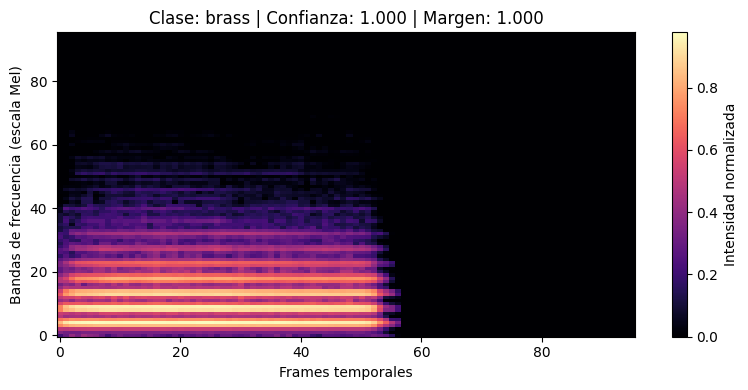

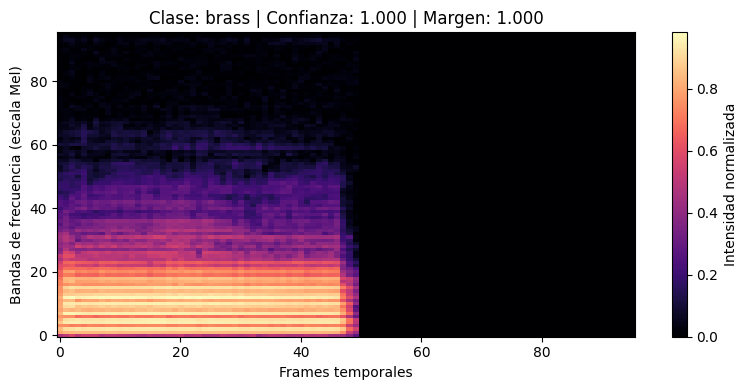

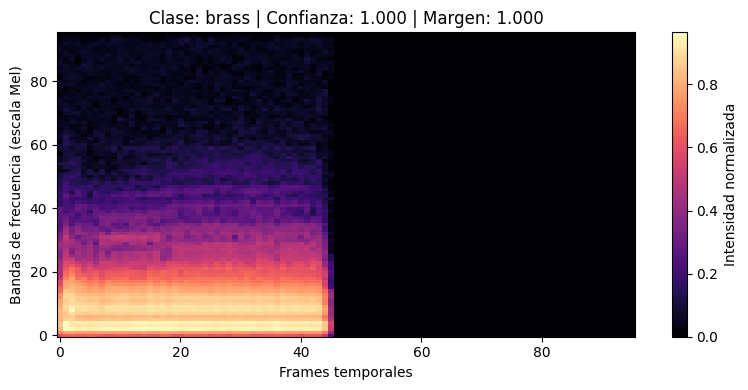

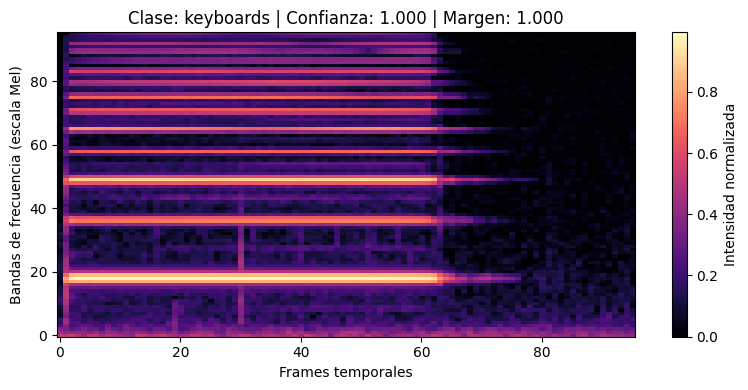

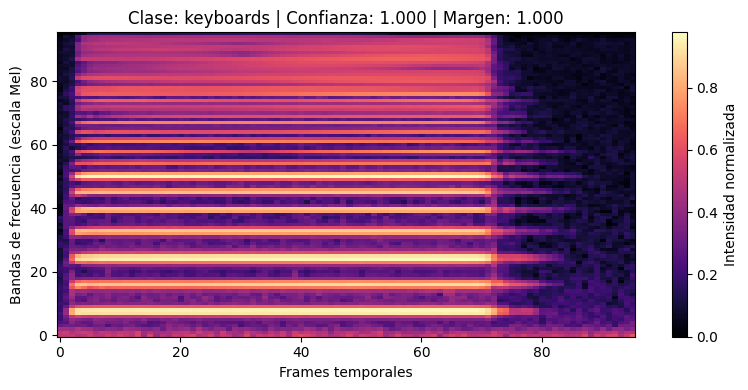

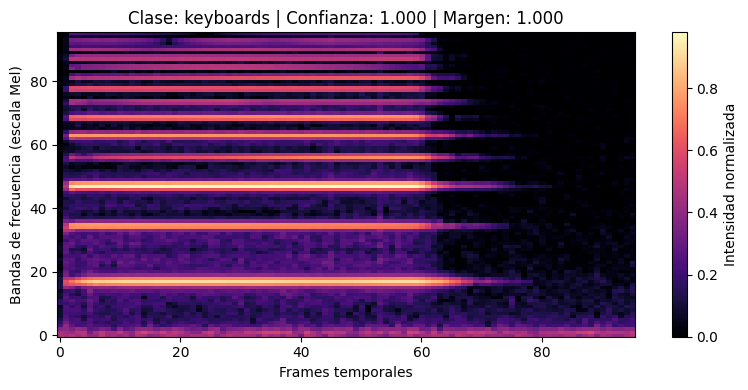

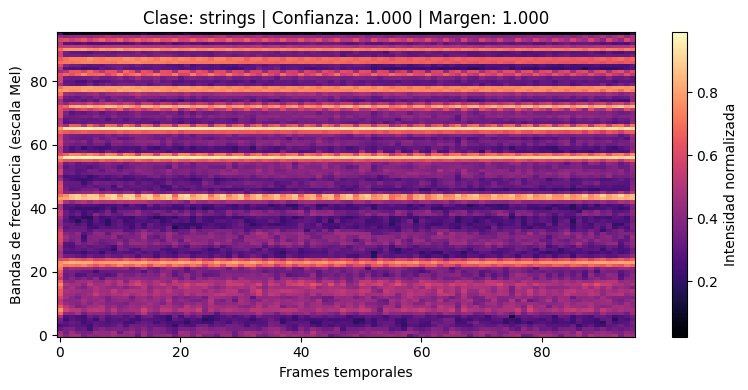

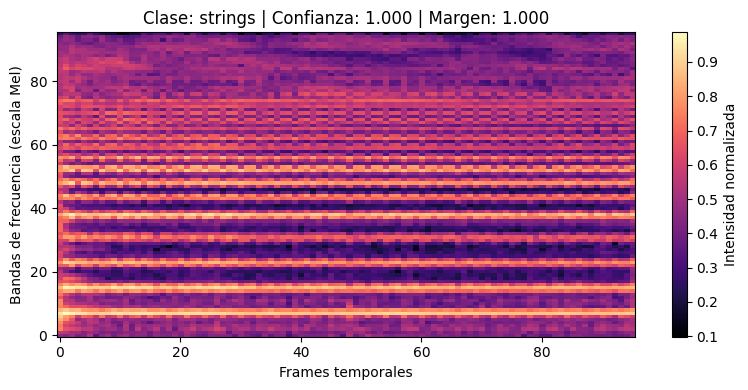

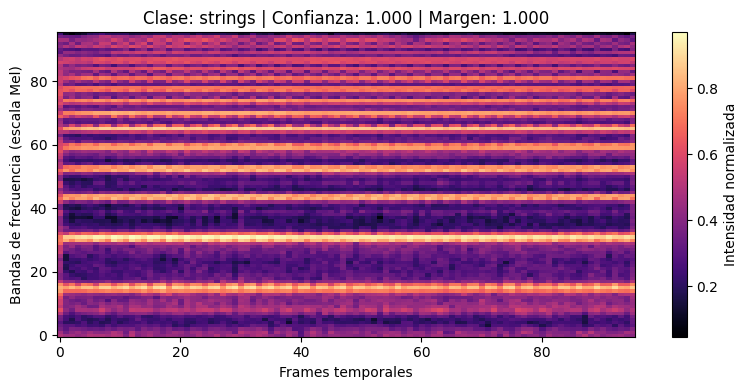

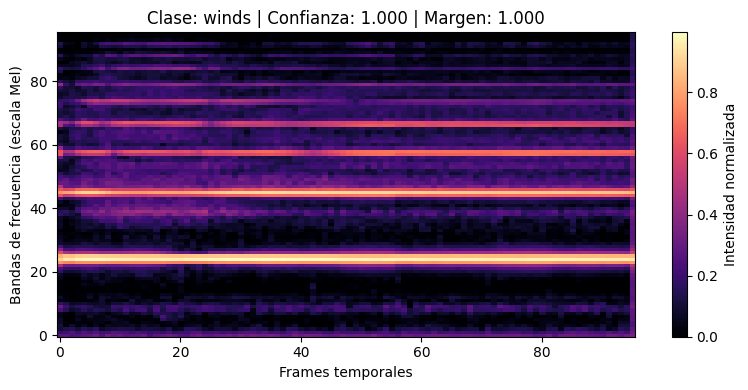

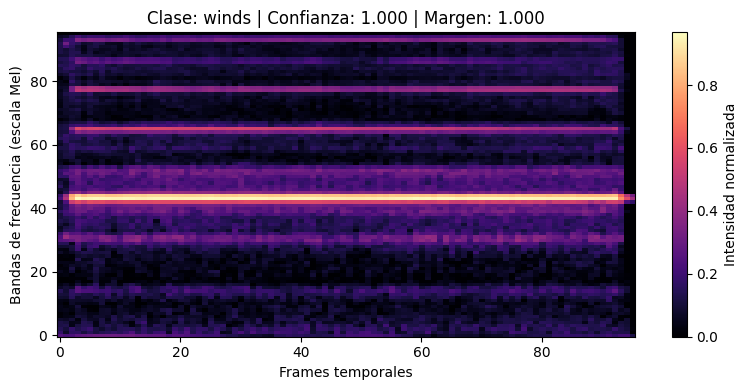

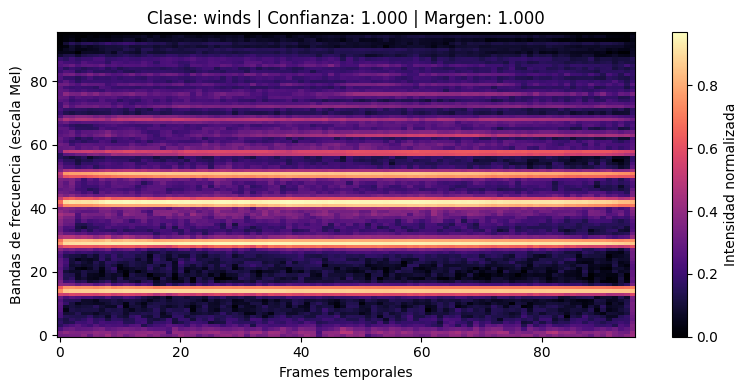

In [30]:
for _, row in top_correct_per_class.iterrows():
    show_correct_case(row)

### 3.2.2 Análisis de errores

Se analizan las muestras mal clasificadas del conjunto de test para estudiar en qué casos falla el modelo y qué familias instrumentales tienden a confundirse entre sí.

El análisis distingue dos tipos de errores:

- **Errores con alta confianza:** casos en los que el modelo asigna una probabilidad elevada a una clase incorrecta. Estos errores pueden indicar patrones mal aprendidos o sesgos en la representación.
- **Errores ambiguos:** casos en los que el margen entre las dos clases más probables es reducido. Estos errores suelen aparecer cuando la muestra comparte características acústicas con varias familias.

Además, se agrupan las predicciones incorrectas por pares de clases reales y predichas para identificar las confusiones más frecuentes.

In [31]:
#Función auxiliar: Visualización de un error
def show_error_case(row):
    idx = results_df.index[results_df["path"] == row["path"]][0]
    spec = specs_test[idx]

    true_idx = int(row["true_idx"])
    pred_idx = int(row["pred_idx"])

    pred_prob = float(row["probs"][pred_idx])
    true_prob = float(row["probs"][true_idx])

    plt.figure(figsize=(8, 4))
    plt.imshow(spec[:, :, 0], aspect="auto", origin="lower", cmap="magma")

    plt.title(
        f"Real: {row['true_class']} ({true_prob:.3f}) | "
        f"Predicción: {row['pred_class']} ({pred_prob:.3f}) | "
        f"Margen: {row['margin']:.3f}"
    )

    plt.xlabel("Frames temporales")
    plt.ylabel("Bandas de frecuencia (escala Mel)")

    plt.colorbar(label="Intensidad normalizada")

    plt.tight_layout()
    plt.show()

In [32]:
errors_df = results_df[results_df["correct"] == 0].copy()

print("Errores:", len(errors_df))

Errores: 18


In [33]:
confusions_df = (
    errors_df
    .groupby(["true_class", "pred_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(confusions_df.head(10))

  true_class pred_class  count
3      winds      brass      9
0      brass      winds      5
2    strings      brass      2
1  keyboards    strings      1
4      winds    strings      1


In [34]:
#Confusiones mas típicas
top_pairs = confusions_df.head(5)
print(top_pairs)

  true_class pred_class  count
3      winds      brass      9
0      brass      winds      5
2    strings      brass      2
1  keyboards    strings      1
4      winds    strings      1


In [35]:
top_confident_errors = errors_df.sort_values("confidence", ascending=False).head(4)
top_confident_errors[["true_class", "pred_class", "confidence", "margin", "path"]]

,true_class,pred_class,confidence,margin,path
388,winds,strings,0.979094,0.970490,/content/drive/MyDrive/TINYSOL/Winds/Sax_Alto/...
327,brass,winds,0.968260,0.936608,/content/drive/MyDrive/TINYSOL/Brass/Trombone/...
29,strings,brass,0.938534,0.903581,/content/drive/MyDrive/TINYSOL/Strings/Violin/...
376,brass,winds,0.844487,0.689572,/content/drive/MyDrive/TINYSOL/Brass/Trombone/...


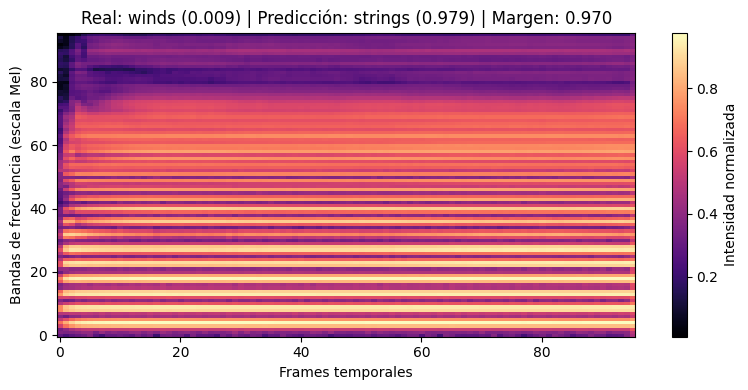

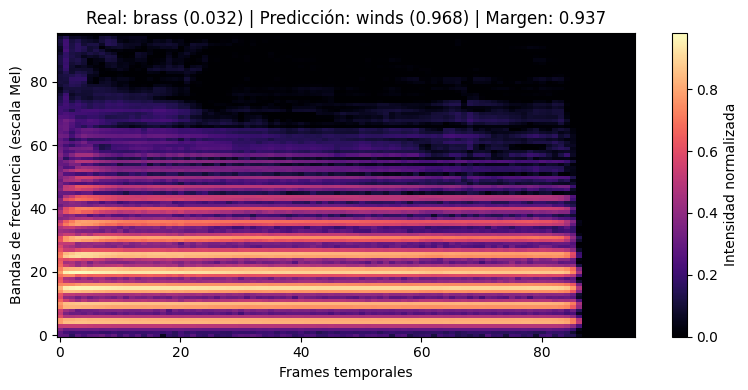

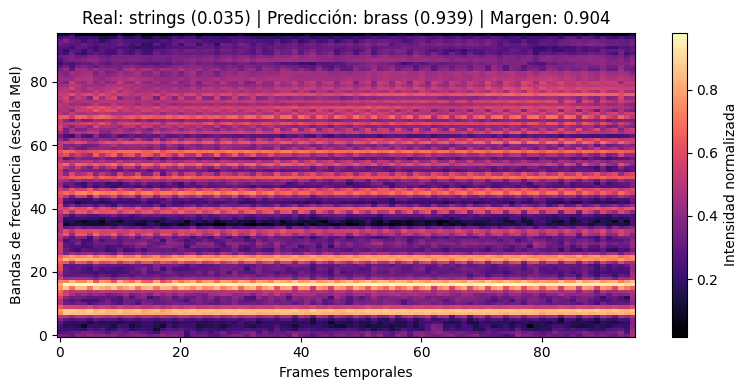

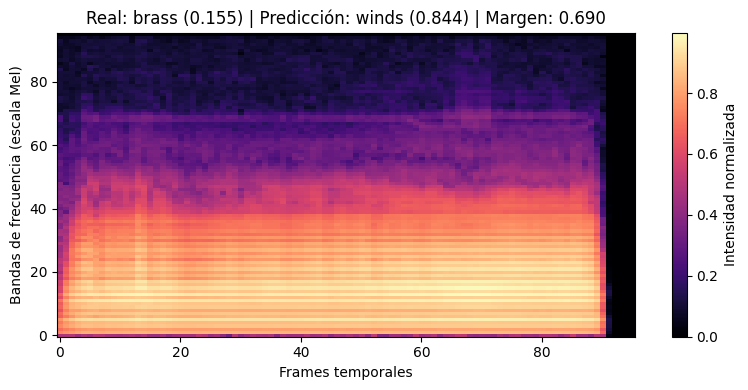

In [36]:
for _, row in top_confident_errors.iterrows():
    show_error_case(row)

In [37]:
most_confused_errors = errors_df.sort_values("margin", ascending=True).head(4)
most_confused_errors[["true_class", "pred_class", "confidence", "margin", "path"]]

,true_class,pred_class,confidence,margin,path
311,winds,brass,0.508021,0.016101,/content/drive/MyDrive/TINYSOL/Winds/Bassoon/o...
115,brass,winds,0.518916,0.038047,/content/drive/MyDrive/TINYSOL/Brass/Trombone/...
45,winds,brass,0.543354,0.086873,/content/drive/MyDrive/TINYSOL/Winds/Bassoon/o...
71,winds,brass,0.546494,0.094641,/content/drive/MyDrive/TINYSOL/Winds/Bassoon/o...


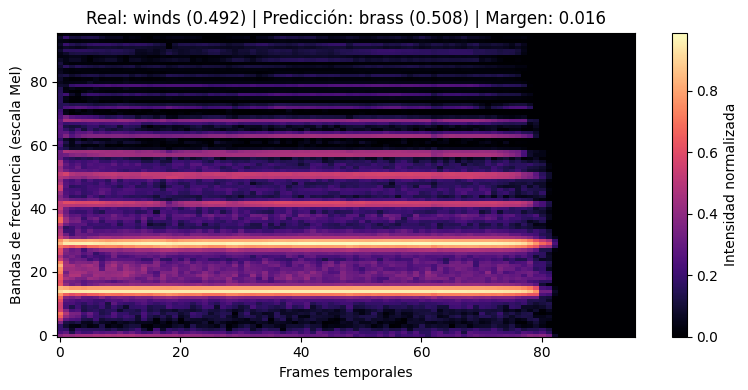

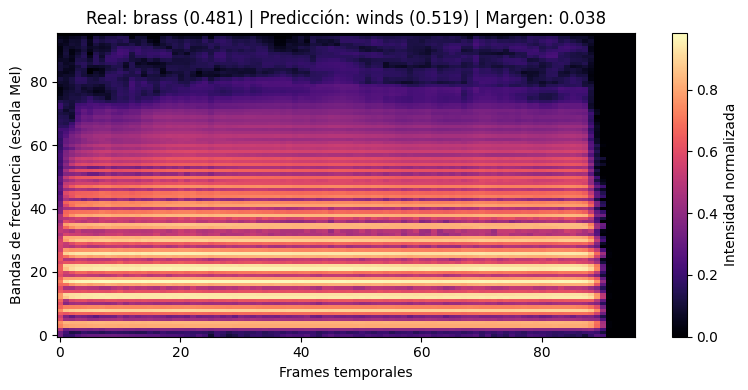

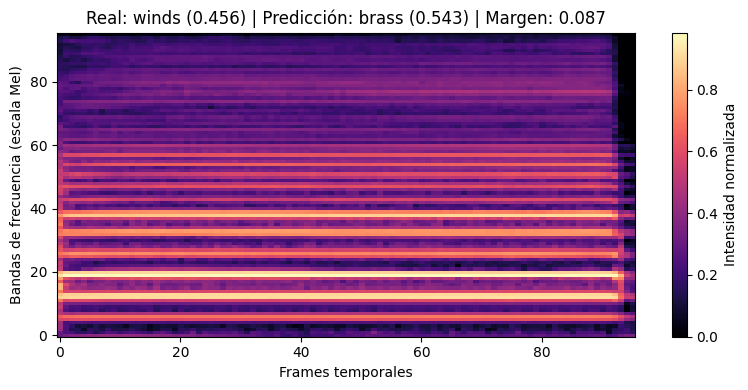

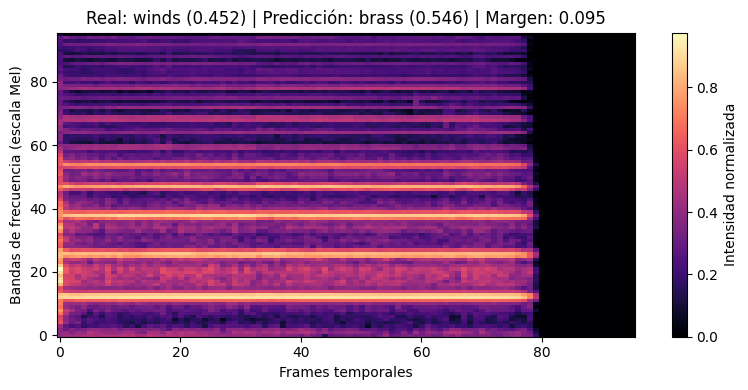

In [38]:
for _, row in most_confused_errors.iterrows():
    show_error_case(row)

# 4 Evaluación sobre datos externos

Para analizar la capacidad de generalización del modelo fuera del dataset de entrenamiento, se realiza una validación utilizando datasets externos independientes. Estas muestras no han sido utilizadas durante el entrenamiento ni durante el ajuste de hiperparámetros, por lo que permiten evaluar el comportamiento del modelo ante datos procedentes de distribuciones distintas.


## 4.1 Philharmonia Orchestra Dataset

El conjunto de datos Philharmonia contiene grabaciones de notas individuales de instrumentos reales etiquetadas por instrumento, dinámica y técnica de interpretación.

La evaluación se realiza únicamente sobre las familias **brass**, **strings** y **winds**, ya que el dataset no contiene una alternativa equivalente al acordeón empleado en la familia **keyboards** dentro de TinySOL.

Las muestras externas se procesan utilizando exactamente el mismo pipeline aplicado durante el entrenamiento: carga de audio, ajuste de duración, generación del espectrograma Mel, transformación a escala logarítmica, normalización y redimensionado. Esto permite que las diferencias observadas en el rendimiento se deban principalmente a cambios en los datos y no a modificaciones en el preprocesado.

Además de calcular las métricas globales de clasificación, se almacena información detallada de cada predicción, incluyendo la clase real, la clase predicha, la confianza del modelo y los errores cometidos.

In [39]:
ext_X = []
ext_y = []
ext_paths = []

ext_familias = ["Brass", "Strings", "Winds"]

for ext_familia in ext_familias:
    ext_carpeta = os.path.join("/content/drive/MyDrive/Validacion", ext_familia)
    for ext_file in os.listdir(ext_carpeta):
        if ext_file.lower().endswith((".wav", ".mp3", ".flac", ".aiff", ".aif")):
            ext_path = os.path.join(ext_carpeta, ext_file)

            try:
                ext_img = load_audio_make_mel(ext_path)
                ext_X.append(ext_img)
                ext_y.append(class_names.index(ext_familia.lower()))
                ext_paths.append(ext_path)

            except Exception as ext_error:
                print("Error con:", ext_path, ext_error)

ext_X = np.array(ext_X, dtype=np.float32)
ext_y = np.array(ext_y)

print("Muestras externas:", ext_X.shape)
print("Distribución:", np.unique(ext_y, return_counts=True))

ext_probs = model.predict(ext_X)
ext_y_pred = np.argmax(ext_probs, axis=1)

ext_accuracy = accuracy_score(ext_y, ext_y_pred)

print("Accuracy externa:", ext_accuracy)
print()

print(classification_report(
    ext_y,
    ext_y_pred,
    labels=[class_names.index(c.lower()) for c in ext_familias],
    target_names=[c.lower() for c in ext_familias]
))

ext_resultados = pd.DataFrame({
    "path": ext_paths,
    "archivo": [os.path.basename(p) for p in ext_paths],
    "real": [class_names[i] for i in ext_y],
    "pred": [class_names[i] for i in ext_y_pred],
    "confidence": np.max(ext_probs, axis=1),
    "correcto": ext_y == ext_y_pred
})

display(ext_resultados)

ext_errores = ext_resultados[ext_resultados["correcto"] == False].sort_values(
    "confidence",
    ascending=False
)

print("Número de errores:", len(ext_errores))
display(ext_errores[["archivo", "real", "pred", "confidence"]])

Muestras externas: (180, 96, 96, 1)
Distribución: (array([0, 2, 3]), array([60, 60, 60]))
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
Accuracy externa: 0.3277777777777778

              precision    recall  f1-score   support

       brass       0.32      0.78      0.45        60
     strings       0.30      0.05      0.09        60
       winds       0.64      0.15      0.24        60

   micro avg       0.35      0.33      0.34       180
   macro avg       0.42      0.33      0.26       180
weighted avg       0.42      0.33      0.26       180



,path,archivo,real,pred,confidence,correcto
0,/content/drive/MyDrive/Validacion/Brass/trombo...,trombone_Cs5_15_fortissimo_normal.mp3,brass,brass,0.999543,True
1,/content/drive/MyDrive/Validacion/Brass/trombo...,trombone_F3_025_mezzo-forte_normal.mp3,brass,brass,0.964827,True
2,/content/drive/MyDrive/Validacion/Brass/trombo...,trombone_As2_very-long_piano_normal.mp3,brass,brass,0.857462,True
3,/content/drive/MyDrive/Validacion/Brass/trombo...,trombone_Fs4_05_fortissimo_normal.mp3,brass,brass,0.990898,True
4,/content/drive/MyDrive/Validacion/Brass/trombo...,trombone_A2_025_piano_normal.mp3,brass,brass,0.985355,True
...,...,...,...,...,...,...
175,/content/drive/MyDrive/Validacion/Winds/oboe_B...,oboe_B3_025_piano_normal.mp3,winds,brass,0.902430,False
176,/content/drive/MyDrive/Validacion/Winds/oboe_A...,oboe_A4_15_mezzo-forte_normal.mp3,winds,brass,0.593713,False
177,/content/drive/MyDrive/Validacion/Winds/oboe_G...,oboe_G4_15_forte_normal.mp3,winds,keyboards,0.855565,False
178,/content/drive/MyDrive/Validacion/Winds/oboe_E...,oboe_E5_05_piano_normal.mp3,winds,brass,0.989435,False


Número de errores: 121


,archivo,real,pred,confidence
19,trumpet_As4_phrase_mezzo-forte_staccato.mp3,brass,winds,0.999991
69,viola_Ds4_1_mezzo-forte_molto-vibrato.mp3,strings,brass,0.999891
60,viola_C5_1_piano_arco-normal.mp3,strings,brass,0.999775
113,violin_Gs7_1_mezzo-forte_natural-harmonic.mp3,strings,brass,0.999774
138,clarinet_Cs4_05_forte_normal.mp3,winds,brass,0.999741
...,...,...,...,...
59,trombone_A2_phrase_mezzo-forte_staccato.mp3,brass,strings,0.524556
42,french-horn_A2_15_fortissimo_normal.mp3,brass,strings,0.509829
29,trumpet_F5_15_pianissimo_normal.mp3,brass,winds,0.496289
20,trumpet_F3_15_pianissimo_normal.mp3,brass,strings,0.457819


## 4.2 IRMAS

El dataset IRMAS (*Instrument Recognition in Musical Audio Signals*) contiene fragmentos de música real extraídos de grabaciones procedentes de distintas fuentes y condiciones acústicas. A diferencia de TinySOL o Philharmonia, las muestras incluyen acompañamiento musical, variaciones de interpretación y entornos acústicos más complejos.

Para la validación externa se seleccionan **120 muestras por familia instrumental** (**480 muestras en total**) correspondientes a instrumentos equivalentes a los utilizados durante el entrenamiento. Esta evaluación permite analizar el comportamiento del modelo en un escenario más cercano a situaciones reales, donde las señales presentan una mayor variabilidad y ruido contextual.

Las muestras se procesan utilizando el mismo pipeline de preprocesado empleado durante el entrenamiento.

In [40]:
ext_X = []
ext_y = []
ext_paths = []

ext_familias = ["Brass", "Strings", "Winds", "Keyboards"]

for ext_familia in ext_familias:
    ext_carpeta = os.path.join("/content/drive/MyDrive/Validacion2_procesada", ext_familia)

    for ext_file in os.listdir(ext_carpeta):
        if ext_file.lower().endswith((".wav", ".mp3", ".flac", ".aiff", ".aif")):
            ext_path = os.path.join(ext_carpeta, ext_file)

            try:
                ext_img = load_audio_make_mel(ext_path)
                ext_X.append(ext_img)
                ext_y.append(class_names.index(ext_familia.lower()))
                ext_paths.append(ext_path)

            except Exception as ext_error:
                print("Error con:", ext_path, ext_error)

ext_X = np.array(ext_X, dtype=np.float32)
ext_y = np.array(ext_y)

print("Muestras externas:", ext_X.shape)
print("Distribución:", np.unique(ext_y, return_counts=True))

ext_probs = model.predict(ext_X)
ext_y_pred = np.argmax(ext_probs, axis=1)

ext_accuracy = accuracy_score(ext_y, ext_y_pred)

print("Accuracy externa:", ext_accuracy)
print()

print(classification_report(
    ext_y,
    ext_y_pred,
    labels=[class_names.index(c.lower()) for c in ext_familias],
    target_names=[c.lower() for c in ext_familias]
))

ext_resultados = pd.DataFrame({
    "path": ext_paths,
    "archivo": [os.path.basename(p) for p in ext_paths],
    "real": [class_names[i] for i in ext_y],
    "pred": [class_names[i] for i in ext_y_pred],
    "confidence": np.max(ext_probs, axis=1),
    "correcto": ext_y == ext_y_pred
})

display(ext_resultados)

ext_errores = ext_resultados[ext_resultados["correcto"] == False].sort_values(
    "confidence",
    ascending=False
)

print("Número de errores:", len(ext_errores))
display(ext_errores[["archivo", "real", "pred", "confidence"]])

Muestras externas: (480, 96, 96, 1)
Distribución: (array([0, 1, 2, 3]), array([120, 120, 120, 120]))
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Accuracy externa: 0.24166666666666667

              precision    recall  f1-score   support

       brass       0.24      0.75      0.36       120
     strings       0.26      0.21      0.23       120
       winds       1.00      0.01      0.02       120
   keyboards       0.00      0.00      0.00       120

    accuracy                           0.24       480
   macro avg       0.37      0.24      0.15       480
weighted avg       0.37      0.24      0.15       480



,path,archivo,real,pred,confidence,correcto
0,/content/drive/MyDrive/Validacion2_procesada/B...,[tru][jaz_blu]1889__1.wav,brass,brass,0.706756,True
1,/content/drive/MyDrive/Validacion2_procesada/B...,[tru][pop_roc]1995__2.wav,brass,strings,0.680000,False
2,/content/drive/MyDrive/Validacion2_procesada/B...,[tru][jaz_blu]1897__3.wav,brass,brass,0.998760,True
3,/content/drive/MyDrive/Validacion2_procesada/B...,[tru][pop_roc]2041__2.wav,brass,brass,0.733774,True
4,/content/drive/MyDrive/Validacion2_procesada/B...,[tru][jaz_blu]1945__2.wav,brass,brass,0.840634,True
...,...,...,...,...,...,...
475,/content/drive/MyDrive/Validacion2_procesada/K...,[org][pop_roc]1220__1.wav,keyboards,brass,0.882437,False
476,/content/drive/MyDrive/Validacion2_procesada/K...,238__[org][dru][jaz_blu]1125__1.wav,keyboards,brass,0.940384,False
477,/content/drive/MyDrive/Validacion2_procesada/K...,[pia][pop_roc]1537__1.wav,keyboards,brass,0.990839,False
478,/content/drive/MyDrive/Validacion2_procesada/K...,[pia][jaz_blu]1533__3.wav,keyboards,strings,0.493319,False


Número de errores: 364


,archivo,real,pred,confidence
215,[vio][jaz_blu]2242__1.wav,strings,brass,0.999980
150,[vio][jaz_blu]2242__3.wav,strings,brass,0.999977
404,[org][pop_roc]1046__1.wav,keyboards,brass,0.999872
471,[pia][jaz_blu]1483__3.wav,keyboards,brass,0.999409
443,[org][pop_roc]1227__1.wav,keyboards,brass,0.998934
...,...,...,...,...
94,[tru][jaz_blu]2029__1.wav,brass,strings,0.503600
300,[cla][pop_roc]0198__1.wav,winds,brass,0.503364
193,[vio][pop_roc]2127__3.wav,strings,brass,0.503013
340,[flu][jaz_blu]0445__3.wav,winds,strings,0.495160


### 4.3 NSynth
Notas musicales aisladas de 4 segundos generadas a partir de librerías
de samples comerciales. Se evalúa sobre 3 familias (brass, strings, winds)
con 180 muestras por clase, excluyendo keyboards por falta de equivalente
al acordeón de TinySOL.

In [41]:
ext_X = []
ext_y = []
ext_paths = []

ext_familias = ["Brass", "Strings", "Winds"]

for ext_familia in ext_familias:
    ext_carpeta = os.path.join("/content/drive/MyDrive/Validacion_NSynth_v2", ext_familia)

    for ext_file in os.listdir(ext_carpeta):
        if ext_file.lower().endswith((".wav", ".mp3", ".flac", ".aiff", ".aif")):
            ext_path = os.path.join(ext_carpeta, ext_file)

            try:
                ext_img = load_audio_make_mel(ext_path)
                ext_X.append(ext_img)
                ext_y.append(class_names.index(ext_familia.lower()))
                ext_paths.append(ext_path)

            except Exception as ext_error:
                print("Error con:", ext_path, ext_error)

ext_X = np.array(ext_X, dtype=np.float32)
ext_y = np.array(ext_y)

print("Muestras externas:", ext_X.shape)
print("Distribución:", np.unique(ext_y, return_counts=True))

ext_probs = model.predict(ext_X)
ext_y_pred = np.argmax(ext_probs, axis=1)

ext_accuracy = accuracy_score(ext_y, ext_y_pred)

print("Accuracy externa:", ext_accuracy)
print()

print(classification_report(
    ext_y,
    ext_y_pred,
    labels=[class_names.index(c.lower()) for c in ext_familias],
    target_names=[c.lower() for c in ext_familias]
))

ext_resultados = pd.DataFrame({
    "path": ext_paths,
    "archivo": [os.path.basename(p) for p in ext_paths],
    "real": [class_names[i] for i in ext_y],
    "pred": [class_names[i] for i in ext_y_pred],
    "confidence": np.max(ext_probs, axis=1),
    "correcto": ext_y == ext_y_pred
})

display(ext_resultados)

ext_errores = ext_resultados[ext_resultados["correcto"] == False].sort_values(
    "confidence",
    ascending=False
)

print("Número de errores:", len(ext_errores))
display(ext_errores[["archivo", "real", "pred", "confidence"]])

Muestras externas: (540, 96, 96, 1)
Distribución: (array([0, 2, 3]), array([180, 180, 180]))
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
Accuracy externa: 0.3925925925925926

              precision    recall  f1-score   support

       brass       0.33      0.72      0.45       180
     strings       0.73      0.19      0.31       180
       winds       0.70      0.27      0.39       180

   micro avg       0.41      0.39      0.40       540
   macro avg       0.58      0.39      0.38       540
weighted avg       0.58      0.39      0.38       540



,path,archivo,real,pred,confidence,correcto
0,/content/drive/MyDrive/Validacion_NSynth_v2/Br...,brass_acoustic_046-058-127.wav,brass,brass,0.997803,True
1,/content/drive/MyDrive/Validacion_NSynth_v2/Br...,brass_acoustic_006-044-025.wav,brass,brass,0.801231,True
2,/content/drive/MyDrive/Validacion_NSynth_v2/Br...,brass_acoustic_046-107-050.wav,brass,brass,0.943550,True
3,/content/drive/MyDrive/Validacion_NSynth_v2/Br...,brass_acoustic_006-062-050.wav,brass,brass,0.865927,True
4,/content/drive/MyDrive/Validacion_NSynth_v2/Br...,brass_acoustic_016-080-075.wav,brass,keyboards,0.955310,False
...,...,...,...,...,...,...
535,/content/drive/MyDrive/Validacion_NSynth_v2/Wi...,flute_synthetic_000-084-025.wav,winds,brass,0.824606,False
536,/content/drive/MyDrive/Validacion_NSynth_v2/Wi...,flute_synthetic_000-086-025.wav,winds,brass,0.831065,False
537,/content/drive/MyDrive/Validacion_NSynth_v2/Wi...,flute_synthetic_000-055-050.wav,winds,winds,0.765178,True
538,/content/drive/MyDrive/Validacion_NSynth_v2/Wi...,flute_synthetic_000-063-075.wav,winds,brass,0.510504,False


Número de errores: 328


,archivo,real,pred,confidence
399,flute_synthetic_000-022-100.wav,winds,brass,0.999889
425,flute_synthetic_000-023-100.wav,winds,brass,0.999877
391,flute_synthetic_000-021-127.wav,winds,brass,0.999877
442,flute_synthetic_000-024-050.wav,winds,brass,0.999876
374,flute_synthetic_000-025-100.wav,winds,brass,0.999855
...,...,...,...,...
152,brass_acoustic_006-065-050.wav,brass,winds,0.497844
175,brass_acoustic_006-065-025.wav,brass,winds,0.497833
528,flute_acoustic_002-099-075.wav,winds,brass,0.410149
362,flute_acoustic_002-099-050.wav,winds,brass,0.408321
